In [1]:
import bayesian_stats_course_tools
bayesian_stats_course_tools.misc.load_tex_defs()

import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

To create your own package, have a look at the example in `course_tools` and the documentation at https://packaging.python.org/en/latest/tutorials/packaging-projects/.

The key files are
- The `pyproject.toml` file, which specifies that this is a python package
- The `src/bayesian_stats_course_tools/__init__.py`, which makes `bayesian_stats_course_tools` a python module that can be imported.

In [2]:
# %pip install --user -e ~/Bayesian-Stats-HS2026/course_tools

### Exercise

1. Create a new directory at the top of the JupyterLab file system
2. Create a new Python notebook

3. Obtain an estimate of the value of $\pi$
    - From the definition in `numpy`
    - Using an analytic series expansion: $\pi = 4 \sum_{k=0}^\infty \frac{(-1)^{k}}{2k + 1}$
    - Using a Monte-Carlo estimate: 
        1. Sample $n$ points uniformly on the unit square using `numpy.random.uniform`
        2. Count the number $n_{<r}$ of points with distance $r = \sqrt{x^2+y^2} \leq 1$
        3. Compare the fraction $\frac{n_{<r}}{n}$ to the ratio of the area of a quadrant of a disc to the area of the square to derive an estimate of $\pi$
    - Bonus: Repeat for (hyper) cube and (hyper) ball in 3 or more dimensions. How does the number of samples required to get a robust estimate of $\pi$ change with the number of dimensions? 

4. Use the debugger to step through some iterations of your code.

5. Create plots showing the estimated value as the number of terms in the series expansion and the number of Monte-Carlo samples is varied

In [2]:
# Exercise Week 1
import numpy as np
import matplotlib.pyplot as plt

# estimating pi from numpy
pi_numpy = np.pi
print("PI from Numpy = ",pi_numpy)



PI from Numpy =  3.141592653589793


In [3]:
# estimation pi from Leibniz series

def Leibniz_pi(n):
    k = np.arange(n)
    terms = (-1)**k / (2*k+1)
    pi = 4 * np.sum(terms)
    return pi

n = 100
print(Leibniz_pi(n))

3.131592903558552


n =         1: 4.0000000000   error = 8.58e-01
n =         2: 2.6666666667   error = 4.75e-01
n =         3: 3.4666666667   error = 3.25e-01
n =         4: 2.8952380952   error = 2.46e-01
n =         5: 3.3396825397   error = 1.98e-01
n =         6: 2.9760461760   error = 1.66e-01
n =         7: 3.2837384837   error = 1.42e-01
n =         8: 3.0170718171   error = 1.25e-01
n =         9: 3.2523659347   error = 1.11e-01
n =        10: 3.0418396189   error = 9.98e-02
n =        11: 3.2323158094   error = 9.07e-02
n =        12: 3.0584027659   error = 8.32e-02
n =        13: 3.2184027659   error = 7.68e-02
n =        14: 3.0702546178   error = 7.13e-02
n =        15: 3.2081856523   error = 6.66e-02
n =        16: 3.0791533942   error = 6.24e-02
n =        17: 3.2003655154   error = 5.88e-02
n =        18: 3.0860798011   error = 5.55e-02
n =        19: 3.1941879092   error = 5.26e-02
n =        20: 3.0916238067   error = 5.00e-02
n =        21: 3.1891847823   error = 4.76e-02
n =        22

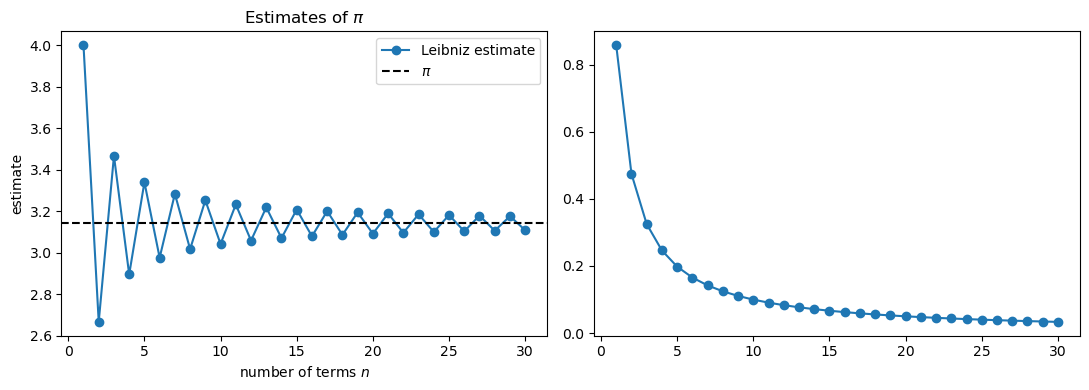

In [4]:
# estimation from Leibniz series for various n

various_n = np.array([n for n in range(1,31)])
estimates = np.array([Leibniz_pi(n) for n in various_n])

for n, est in zip(various_n, estimates):
    print(f"n = {n:>9,}: {est:.10f}   error = {abs(est - np.pi):.2e}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(various_n, estimates, "o-", label="Leibniz estimate")
ax1.axhline(np.pi, ls="--", color="k", label=r"$\pi$")

ax1.set(xlabel="number of terms $n$", ylabel="estimate", title="Estimates of $\\pi$")
ax1.legend()

ax2.plot(various_n, np.abs(estimates - np.pi), "o-")

plt.tight_layout()
plt.show()

In [7]:
# estimation of pi from Monte Carlo estimate

def MonteCarlo_pi(n):
    points = np.random.uniform(0, 1, size=(n, 2))
    inside = np.sum(points**2, axis=1) <= 1
    return 4 * np.mean(inside)

various_n = 10 ** np.arange(1, 7)   # 10, 100, ..., 1,000,000

for n in various_n:
    print(MonteCarlo_pi(n))

    

2.4
3.04
3.088
3.1548
3.14828
3.1416
